# Advanced Analytics — Mutual Fund & Investor Analysis

## Objective

This notebook extends the performance analysis by evaluating:

1. Historical VaR and CVaR
2. Rolling 90-day Sharpe Ratio
3. Investor cohort behaviour
4. SIP continuity and investor risk
5. Risk-based fund recommendations
6. Portfolio sector concentration using HHI
7. Advanced business insights

In [151]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [152]:
fund_master = pd.read_csv("../DATA/PROCESSED/01_fund_master.csv")
nav_his = pd.read_csv("../DATA/PROCESSED/02_nav_history.csv")

In [153]:
scheme = pd.merge(
    fund_master,
    nav_his,
    on = "amfi_code"
)

In [154]:
scheme.shape

(46000, 17)

In [155]:
scheme.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'date', 'nav'],
      dtype='object')

In [156]:
scheme.head(10)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-03,54.3856
1,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-04,54.3474
2,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-05,54.6869
3,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-06,55.4550
4,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-07,55.3692
5,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-10,55.2835
6,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-11,56.0878
7,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-12,56.4978
8,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-13,56.2934
9,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-14,56.5926


In [157]:
scheme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           46000 non-null  int64  
 1   fund_house          46000 non-null  object 
 2   scheme_name         46000 non-null  object 
 3   category            46000 non-null  object 
 4   sub_category        46000 non-null  object 
 5   plan                46000 non-null  object 
 6   launch_date         46000 non-null  object 
 7   benchmark           46000 non-null  object 
 8   expense_ratio_pct   46000 non-null  float64
 9   exit_load_pct       46000 non-null  float64
 10  min_sip_amount      46000 non-null  int64  
 11  min_lumpsum_amount  46000 non-null  int64  
 12  fund_manager        46000 non-null  object 
 13  risk_category       46000 non-null  object 
 14  sebi_category_code  46000 non-null  object 
 15  date                46000 non-null  object 
 16  nav 

In [158]:
scheme["date"] = pd.to_datetime(scheme["date"])
scheme["launch_date"] = pd.to_datetime(scheme["launch_date"])

In [159]:
scheme.describe()

,amfi_code,launch_date,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,date,nav
count,46000.000000,46000,46000.000000,46000.000000,46000.0,46000.000000,46000,46000.000000
mean,120247.000000,2007-02-21 10:12:00,1.237000,0.812500,500.0,1277.500000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,1996-09-11 00:00:00,0.550000,0.000000,500.0,100.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2003-12-04 06:00:00,0.787500,1.000000,500.0,1000.000000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2007-04-30 00:00:00,1.425000,1.000000,500.0,1000.000000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2010-10-24 18:00:00,1.540000,1.000000,500.0,1000.000000,2025-04-23 00:00:00,260.338675
max,149324.000000,2015-12-28 00:00:00,1.640000,1.000000,500.0,5000.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,0.381725,0.382226,0.0,1069.237394,NaN,577.187060


In [160]:
fund_name = "HDFC Top 100 Fund - Regular Plan - Growth"

In [161]:
fund = scheme[scheme["scheme_name"] == fund_name].copy()

fund = fund.sort_values("date")

In [162]:
fund["daily_return"] = (fund["nav"].pct_change())

In [163]:
returns = fund["daily_return"].dropna()

In [164]:
var_95 = returns.quantile(0.05)

In [165]:
cvar_95 = returns[returns <= var_95].mean()

In [166]:
print("Fund:", fund_name)
print("VaR 95%:", var_95)
print("CVaR 95%:", cvar_95)

Fund: HDFC Top 100 Fund - Regular Plan - Growth
VaR 95%: -0.014363639988111142
CVaR 95%: -0.01806020763217176


In [167]:
var_results = []

for fund_name in scheme["scheme_name"].unique():

    fund = scheme[
        scheme["scheme_name"] == fund_name
    ].copy()

    fund = fund.sort_values("date")

    returns = fund["nav"].pct_change().dropna()

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append({
        "scheme_name": fund_name,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

In [168]:
# Convert into DataFrame 
var_cvar_report = pd.DataFrame(var_results)

In [169]:
var_cvar_report.head()

,scheme_name,VaR_95,CVaR_95
0,SBI Bluechip Fund - Regular Plan - Growth,-0.012846,-0.016397
1,SBI Bluechip Fund - Direct Plan - Growth,-0.013501,-0.017336
2,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
3,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.003938,-0.005014


In [170]:
var_cvar_report.shape

(40, 3)

In [171]:
var_cvar_report["VaR_95_pct"] = (
    var_cvar_report["VaR_95"] * 100
)

var_cvar_report["CVaR_95_pct"] = (
    var_cvar_report["CVaR_95"] * 100
)

In [172]:
import os

file_path = "../DATA/PROCESSED/var_cvar_report.csv"

if os.path.exists(file_path):
    os.remove(file_path)

var_cvar_report.to_csv(file_path, index=False)

In [173]:
pd.read_csv(
    "../DATA/PROCESSED/var_cvar_report.csv"
).head()

,scheme_name,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
0,SBI Bluechip Fund - Regular Plan - Growth,-0.012846,-0.016397,-1.284623,-1.639681
1,SBI Bluechip Fund - Direct Plan - Growth,-0.013501,-0.017336,-1.350097,-1.733570
2,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,-2.450705,-3.059526
3,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,-2.685944,-3.238412
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.003938,-0.005014,-0.393828,-0.501369


In [174]:
var_cvar_report.sort_values("VaR_95_pct").head(10)

,scheme_name,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
3,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,-2.685944,-3.238412
27,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,-2.618842,-3.166729
29,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,-2.602125,-3.245906
17,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,-2.543811,-3.230407
2,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,-2.450705,-3.059526
39,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036,-2.348307,-3.103625
32,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251,-1.922028,-2.325086
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456,-1.903354,-2.345576
12,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342,-1.889179,-2.434207
26,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260,-1.848028,-2.426006


In [175]:
var_cvar_report.sort_values("CVaR_95_pct").head(10)

,scheme_name,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
29,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,-2.602125,-3.245906
3,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,-2.685944,-3.238412
17,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,-2.543811,-3.230407
27,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,-2.618842,-3.166729
39,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036,-2.348307,-3.103625
2,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,-2.450705,-3.059526
12,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342,-1.889179,-2.434207
26,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260,-1.848028,-2.426006
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456,-1.903354,-2.345576
32,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251,-1.922028,-2.325086


### VaR & CVaR — Key Insight

The Historical 95% VaR analysis shows that the highest downside
risk is concentrated among small-cap funds. SBI Small Cap Fund -
Direct Plan - Growth has the most negative VaR at approximately
-2.69%, followed by Axis Small Cap Fund and ABSL Small Cap Fund.

The CVaR results show that losses become more severe within the
worst 5% of trading days. ABSL Small Cap Fund has the lowest CVaR
at approximately -3.25%, indicating that its average loss during
the extreme downside tail was around 3.25%.

Overall, the analysis suggests that small-cap funds in the
40-scheme dataset have greater historical tail risk than the
mid-cap funds that follow them in the ranking. These results
describe historical downside behaviour and should not be treated
as a prediction of future losses.

### Rolling 90-day Sharpe

In [176]:
top5_funds = [
    "Mirae Asset Large Cap Fund - Regular - Growth",
    "ICICI Pru Midcap Fund - Regular - Growth",
    "Kotak Flexicap Fund - Regular - Growth",
    "HDFC Mid-Cap Opportunities Fund - Regular - Growth",
    "ICICI Pru Bluechip Fund - Direct - Growth"
]

In [177]:
fund_name = top5_funds[0]

fund = scheme[
    scheme["scheme_name"] == fund_name
].copy()

fund = fund.sort_values("date")

In [178]:
fund[["date", "nav"]].head()

,date,nav
39100,2022-01-03,70.2514
39101,2022-01-04,71.6085
39102,2022-01-05,71.3264
39103,2022-01-06,72.1746
39104,2022-01-07,72.2118


In [179]:
fund["daily_return"] = fund["nav"].pct_change()

In [180]:
fund[["date", "nav", "daily_return"]].head()

,date,nav,daily_return
39100,2022-01-03,70.2514,NaN
39101,2022-01-04,71.6085,0.019318
39102,2022-01-05,71.3264,-0.003939
39103,2022-01-06,72.1746,0.011892
39104,2022-01-07,72.2118,0.000515


In [181]:
fund["rolling_mean_90"] = (
    fund["daily_return"].rolling(90).mean()
)

In [182]:
fund["rolling_std_90"] = (
    fund["daily_return"].rolling(90).std()
)

In [183]:

fund["rolling_sharpe_90"] = (
    fund["rolling_mean_90"]
    / fund["rolling_std_90"]
) * np.sqrt(252)

In [184]:
fund[["date",
     "rolling_mean_90",
     "rolling_std_90",
     "rolling_sharpe_90"]].tail()

,date,rolling_mean_90,rolling_std_90,rolling_sharpe_90
40245,2026-05-25,0.000182,0.009439,0.305637
40246,2026-05-26,0.000240,0.009435,0.404207
40247,2026-05-27,0.000083,0.009232,0.143232
40248,2026-05-28,0.000360,0.009115,0.626656
40249,2026-05-29,0.000218,0.009213,0.375893


In [185]:
fund["rolling_sharpe_90"].describe()

count    1060.000000
mean        1.890422
std         1.655802
min        -2.017835
25%         0.740275
50%         1.727258
75%         2.872815
max         6.503566
Name: rolling_sharpe_90, dtype: float64

In [186]:
rolling_sharpe_data = pd.DataFrame()

In [187]:
for fund_name in top5_funds:

    fund = scheme[
    scheme["scheme_name"] == fund_name].copy()

    fund = fund.sort_values("date")

    fund["daily_return"] = fund["nav"].pct_change()

    fund["rolling_mean_90"] = (
        fund["daily_return"].rolling(90).mean())

    fund["rolling_std_90"] = (
        fund["daily_return"].rolling(90).std())

    fund["rolling_sharpe_90"] = (
        fund["rolling_mean_90"] / fund["rolling_std_90"]) * np.sqrt(252)

    temp = fund[
        ["date", "rolling_sharpe_90"]].dropna()

    temp["scheme_name"] = fund_name

    rolling_sharpe_data = pd.concat(
        [rolling_sharpe_data, temp],
        ignore_index=True)

In [188]:
rolling_sharpe_data.head()

,date,rolling_sharpe_90,scheme_name
0,2022-05-09,3.617161,Mirae Asset Large Cap Fund - Regular - Growth
1,2022-05-10,3.063658,Mirae Asset Large Cap Fund - Regular - Growth
2,2022-05-11,3.059708,Mirae Asset Large Cap Fund - Regular - Growth
3,2022-05-12,2.859032,Mirae Asset Large Cap Fund - Regular - Growth
4,2022-05-13,2.700937,Mirae Asset Large Cap Fund - Regular - Growth


In [189]:
rolling_sharpe_data.isna().sum()

date                 0
rolling_sharpe_90    0
scheme_name          0
dtype: int64

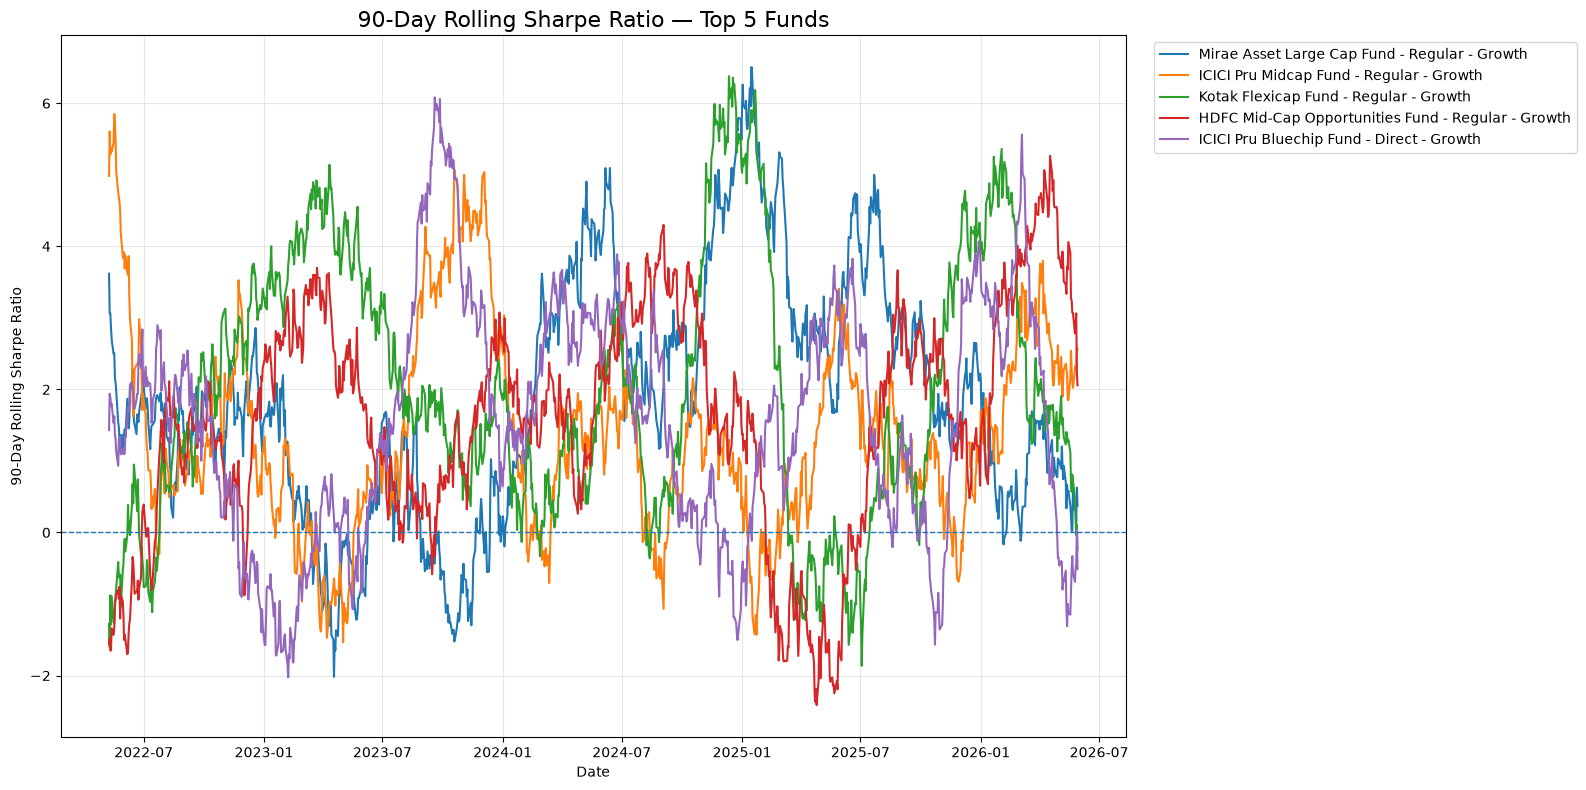

In [190]:
plt.figure(figsize=(16, 8))

for fund_name in top5_funds:

    fund_data = rolling_sharpe_data[
        rolling_sharpe_data["scheme_name"] == fund_name]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=fund_name)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1)

plt.title(
    "90-Day Rolling Sharpe Ratio — Top 5 Funds", fontsize=16)

plt.xlabel("Date")
plt.ylabel("90-Day Rolling Sharpe Ratio")

plt.legend(
    bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../REPORTS/Charts/rolling_sharpe_chart.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Rolling 90-Day Sharpe — Key Insight

The 90-day rolling Sharpe ratio shows that risk-adjusted performance
varies considerably over time across the selected funds. Periods
with higher rolling Sharpe values indicate stronger returns relative
to recent volatility, while negative values indicate periods of
unfavourable risk-adjusted performance.

The rolling analysis provides a more dynamic view of fund performance
than a single overall Sharpe ratio because it identifies periods in
which risk-adjusted performance strengthened or deteriorated.

### Investor cohort analysis

In [191]:
investor = pd.read_csv("../DATA/PROCESSED/08_investor_transactions.csv")
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,01-01-2024,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,01-01-2024,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,01-01-2024,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,01-01-2024,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,01-01-2024,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [192]:
investor.shape

(32778, 13)

In [193]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [194]:
investor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [195]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"], format="%d-%m-%Y")

In [196]:
first_transaction = (
    investor
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

In [197]:
first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

In [198]:
first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [199]:
first_transaction["cohort_year"].value_counts().sort_index()

cohort_year
2024    4803
2025     197
Name: count, dtype: int64

In [200]:
investor = investor.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [201]:
investor[["investor_id",
          "transaction_date",
          "amount_inr",
          "cohort_year"]].head(10)

,investor_id,transaction_date,amount_inr,cohort_year
0,INV003054,2024-01-01,1834,2024
1,INV002952,2024-01-01,392882,2024
2,INV003420,2024-01-01,912,2024
3,INV003436,2024-01-01,1102,2024
4,INV004691,2024-01-01,8682,2024
5,INV001497,2024-01-01,3295,2024
6,INV000786,2024-01-01,15047,2024
7,INV000616,2024-01-01,933,2024
8,INV003670,2024-01-01,10672,2024
9,INV002054,2024-01-01,1111,2024


In [202]:
cohort_investors = (
    investor
    .groupby("cohort_year")["investor_id"]
    .nunique()
    .reset_index(name="investor_count")
)

In [203]:
cohort_avg_amount = (
    investor
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_investment_inr")
)

In [204]:
cohort_total = (
    investor
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

In [205]:
cohort_analysis = (
    cohort_investors
    .merge(
        cohort_avg_amount,
        on="cohort_year"
    )
    .merge(
        cohort_total,
        on="cohort_year"
    )
)

In [206]:
cohort_analysis

,cohort_year,investor_count,avg_investment_inr,total_invested_inr
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [207]:
cohort_analysis["total_invested_crore"] = (
    cohort_analysis["total_invested_inr"] / 1e7
)

In [208]:
cohort_analysis

,cohort_year,investor_count,avg_investment_inr,total_invested_inr,total_invested_crore
0,2024,4803,107422.541832,3491125187,349.112519
1,2025,197,109158.577061,30455243,3.045524


In [209]:
cohort_fund_counts = (
    investor
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transaction_count")
)

In [210]:
top_fund_by_cohort = (
    cohort_fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

In [211]:
top_fund_by_cohort

,cohort_year,amfi_code,transaction_count
35,2024,148568,874
62,2025,119599,12


In [212]:
fund_master[
    fund_master["amfi_code"].isin(
        top_fund_by_cohort["amfi_code"]
    )
][
    ["amfi_code", "scheme_name"]
]

,amfi_code,scheme_name
3,119599,SBI Small Cap Fund - Direct Plan - Growth
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...


### Investor Cohort Analysis — Preliminary Insight

The investor dataset is heavily concentrated in the 2024 cohort,
which contains 4,803 investors compared with 197 investors in the
2025 cohort. The 2024 cohort also accounts for approximately
₹349.11 crore in total transaction value, substantially higher than
the ₹3.05 crore recorded for the 2025 cohort.

Despite the large difference in cohort size, the average transaction
amount is relatively similar between the two cohorts, at approximately
₹1.07 lakh for 2024 and ₹1.09 lakh for 2025. Therefore, the large
difference in total investment is primarily associated with the
difference in the number of investors and transactions.

The analysis is based on the available transaction dataset, which
contains identified first-transaction cohorts from 2024 and 2025.

### SIP continuity analysis

In [213]:
investor["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [214]:
investor_sip = investor[investor["transaction_type"] == "SIP"]
investor_sip

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32771,INV002074,2025-05-30,118633,SIP,2383,Karnataka,Bangalore,T30,26-35,Female,6.1,UPI,Verified,2024
32772,INV000339,2025-05-30,148569,SIP,1109,Uttar Pradesh,Kanpur,B30,26-35,Male,22.3,Cheque,Verified,2024
32774,INV001838,2025-05-30,119093,SIP,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified,2024
32775,INV000074,2025-05-30,120504,SIP,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified,2024


In [215]:
sip_counts = (
    investor_sip
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

In [216]:
sip_counts.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [217]:
sip_counts[sip_counts["sip_count"] >= 6].shape

(1362, 2)

In [218]:
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

In [219]:
eligible_investors.head()

3     INV000004
7     INV000008
9     INV000010
10    INV000011
11    INV000012
Name: investor_id, dtype: object

In [220]:
sip_eligible = investor_sip[
    investor_sip["investor_id"].isin(eligible_investors)
].copy()

In [221]:
sip_eligible = sip_eligible.sort_values(
    ["investor_id", "transaction_date"]
)

In [222]:
sip_eligible.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024


In [223]:
sip_eligible["sip_gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [224]:
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_count=("sip_gap_days", "count"),
        avg_gap_days=("sip_gap_days", "mean")
    )
    .reset_index()
)

In [225]:
sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days
0,INV000004,5,85.400000
1,INV000008,5,70.400000
2,INV000010,5,64.800000
3,INV000011,6,40.166667
4,INV000012,7,57.000000
5,INV000013,6,55.333333
6,INV000014,6,75.333333
7,INV000023,7,58.571429
8,INV000028,5,93.600000
9,INV000029,6,60.666667


In [226]:
sip_continuity["risk_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

In [227]:
sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days,risk_status
0,INV000004,5,85.400000,At-Risk
1,INV000008,5,70.400000,At-Risk
2,INV000010,5,64.800000,At-Risk
3,INV000011,6,40.166667,At-Risk
4,INV000012,7,57.000000,At-Risk
5,INV000013,6,55.333333,At-Risk
6,INV000014,6,75.333333,At-Risk
7,INV000023,7,58.571429,At-Risk
8,INV000028,5,93.600000,At-Risk
9,INV000029,6,60.666667,At-Risk


In [228]:
continuity_rate = (
    (sip_continuity["risk_status"] == "Regular").mean()
    * 100
)

In [229]:

at_risk_rate = (
    (sip_continuity["risk_status"] == "At-Risk").mean()
    * 100
)

In [230]:
print(f"SIP Continuity Rate: {continuity_rate:.2f}%")
print(f"At-Risk Rate: {at_risk_rate:.2f}%")

SIP Continuity Rate: 2.20%
At-Risk Rate: 97.80%


### SIP Continuity Analysis — Insight

Among investors with at least six recorded SIP transactions, only
2.20% meet the defined continuity criterion, while 97.80% are flagged
as at-risk because their average gap between SIP transactions exceeds
35 days.

This indicates a high level of irregularity in SIP transaction
frequency within the available dataset. However, the "at-risk"
classification is a rule-based indicator rather than confirmed
investor churn, because a gap of more than 35 days does not necessarily
mean that an investor has permanently stopped investing.

In [231]:
sip_continuity.to_csv(
    "../data/processed/sip_continuity_analysis.csv", index=False)

In [232]:
fund_scorecard = pd.read_csv("../DATA/PROCESSED/fund_scorecard.csv")

In [245]:
fund_scorecard.columns

Index(['final_rank', 'scheme_name', 'CAGR_3Y', 'sharpe_ratio', 'alpha',
       'expense_ratio_pct', 'max_drawdown', 'fund_score', 'risk_grade'],
      dtype='object')

In [234]:
print(fund_master.columns)
print(scheme.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'date', 'nav'],
      dtype='object')


In [235]:
fund_master["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [236]:
fund_master[
    ["scheme_name", "risk_category"]
].drop_duplicates().head(20)

,scheme_name,risk_category
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate
1,SBI Bluechip Fund - Direct Plan - Growth,Moderate
2,SBI Small Cap Fund - Regular Plan - Growth,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,Very High
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate
6,HDFC Top 100 Fund - Direct Plan - Growth,Moderate
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,High
9,HDFC Short Term Debt Fund - Regular - Growth,Low


In [237]:
risk_mapping = {
    "Low": "Low",
    "Moderate": "Moderate",
    "Moderately High": "High",
    "High": "High",
    "Very High": "High"
}

In [238]:
risk_lookup = (
    fund_master[
        ["scheme_name", "risk_category"]
    ]
    .drop_duplicates("scheme_name")
)

risk_lookup["risk_grade"] = (
    risk_lookup["risk_category"].map(risk_mapping)
)

In [239]:
risk_lookup.head()

,scheme_name,risk_category,risk_grade
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,Moderate
1,SBI Bluechip Fund - Direct Plan - Growth,Moderate,Moderate
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,High
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,High
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,Low


In [240]:
fund_scorecard = fund_scorecard.merge(
    risk_lookup[["scheme_name", "risk_grade"]],
    on="scheme_name",
    how="left"
)

In [241]:
fund_scorecard["risk_grade"].value_counts()

risk_grade
High        18
Moderate    16
Low          6
Name: count, dtype: int64

In [242]:
for risk_appetite in ["Low", "Moderate", "High"]:

    recommendations = (
        fund_scorecard[
            fund_scorecard["risk_grade"] == risk_appetite
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )

    print("\n" + "=" * 60)
    print(f"Risk Appetite: {risk_appetite}")
    print("=" * 60)

    print(
        recommendations[
            [
                "scheme_name",
                "risk_grade",
                "sharpe_ratio",
                "CAGR_3Y",
                "fund_score"
            ]
        ].to_string(index=False)
    )


Risk Appetite: Low
                                 scheme_name risk_grade  sharpe_ratio  CAGR_3Y  fund_score
    ICICI Pru Liquid Fund - Regular - Growth        Low      0.495723 7.394286      48.000
        Kotak Liquid Fund - Regular - Growth        Low     -0.088747 6.695972      41.125
SBI Magnum Gilt Fund - Regular Plan - Growth        Low     -0.226575 5.840359      33.750

Risk Appetite: Moderate
                                   scheme_name risk_grade  sharpe_ratio   CAGR_3Y  fund_score
 Mirae Asset Large Cap Fund - Regular - Growth   Moderate      1.448291 34.000916       86.25
     SBI Bluechip Fund - Regular Plan - Growth   Moderate      1.208267 30.456524       75.00
Nippon India Large Cap Fund - Regular - Growth   Moderate      1.081659 22.652360       66.75

Risk Appetite: High
                                  scheme_name risk_grade  sharpe_ratio   CAGR_3Y  fund_score
       Kotak Flexicap Fund - Regular - Growth       High      1.306744 29.582770      82.000
Mirae As

In [246]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [247]:
fund_scorecard.columns

Index(['final_rank', 'scheme_name', 'CAGR_3Y', 'sharpe_ratio', 'alpha',
       'expense_ratio_pct', 'max_drawdown', 'fund_score', 'risk_grade'],
      dtype='object')

In [250]:
portfolio = pd.read_csv("../DATA/PROCESSED/09_portfolio_holdings.csv")

In [251]:
print(portfolio.head())
print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     31-12-2025  
1            88.97            1074.65     31-12-2025  
2           208.45            5964.59     31-12-2025  
3           161.32            3748.82     31-12-2025  
4           725.90            1321.45     31-12-2025  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [252]:
portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"],
    format="%d-%m-%Y"
)

print("Funds:", portfolio["amfi_code"].nunique())
print("Sectors:", portfolio["sector"].nunique())

portfolio["sector"].value_counts()

Funds: 34
Sectors: 14


sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

In [253]:
sector_weights = (
    portfolio
    .groupby(
        ["amfi_code", "sector"],
        as_index=False
    )["weight_pct"]
    .sum()
)

In [254]:
sector_weights[
    sector_weights["amfi_code"] == 119551
]

,amfi_code,sector,weight_pct
108,119551,Automobile,7.20
109,119551,Banking,11.19
110,119551,Diversified,9.90
111,119551,IT,18.22
112,119551,Paints,10.25
113,119551,Pharma,7.97
114,119551,Telecom,13.94
115,119551,Utilities,21.33


In [255]:
test_fund = sector_weights[
    sector_weights["amfi_code"] == 119551
].copy()

test_fund["weight"] = (
    test_fund["weight_pct"] / 100
)

In [256]:
test_fund["weight_squared"] = (
    test_fund["weight"] ** 2
)

In [257]:
test_fund[
    ["sector", "weight_pct", "weight", "weight_squared"]
]

,sector,weight_pct,weight,weight_squared
108,Automobile,7.20,0.0720,0.005184
109,Banking,11.19,0.1119,0.012522
110,Diversified,9.90,0.0990,0.009801
111,IT,18.22,0.1822,0.033197
112,Paints,10.25,0.1025,0.010506
113,Pharma,7.97,0.0797,0.006352
114,Telecom,13.94,0.1394,0.019432
115,Utilities,21.33,0.2133,0.045497


In [258]:
fund_hhi = test_fund["weight_squared"].sum()

print("HHI:", fund_hhi)

HHI: 0.14249103999999999


In [259]:
sector_weights["weight"] = (
    sector_weights["weight_pct"] / 100
)

sector_weights["weight_squared"] = (
    sector_weights["weight"] ** 2
)

hhi = (
    sector_weights
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

In [260]:
hhi.head()

,amfi_code,sector_hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [261]:
hhi_report = hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ].drop_duplicates("amfi_code"),
    on="amfi_code",
    how="left"
)

In [262]:
hhi_report.head()

,amfi_code,sector_hhi,scheme_name,category
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [263]:
hhi_report["category"].value_counts()

category
Equity    34
Name: count, dtype: int64

In [264]:
hhi_report = hhi_report.sort_values(
    "sector_hhi",
    ascending=False
).reset_index(drop=True)

hhi_report.head(10)

,amfi_code,sector_hhi,scheme_name,category
0,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,0.241077,DSP Midcap Fund - Regular - Growth,Equity
5,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,Equity
6,118635,0.237497,Nippon India ETF Nifty 50 BeES,Equity
7,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,Equity
8,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
9,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


In [265]:
hhi_report["concentration"] = pd.cut(
    hhi_report["sector_hhi"],
    bins=[0, 0.10, 0.18, 1],
    labels=[
        "Low Concentration",
        "Moderate Concentration",
        "High Concentration"
    ]
)

In [266]:
hhi_report[
    [
        "scheme_name",
        "sector_hhi",
        "concentration"
    ]
].head(10)

,scheme_name,sector_hhi,concentration
0,Axis Bluechip Fund - Regular - Growth,0.296769,High Concentration
1,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,High Concentration
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,High Concentration
3,UTI Flexi Cap Fund - Regular - Growth,0.251383,High Concentration
4,DSP Midcap Fund - Regular - Growth,0.241077,High Concentration
5,ICICI Pru Midcap Fund - Regular - Growth,0.238695,High Concentration
6,Nippon India ETF Nifty 50 BeES,0.237497,High Concentration
7,SBI Small Cap Fund - Direct Plan - Growth,0.232361,High Concentration
8,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464,High Concentration
9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647,High Concentration


In [267]:
hhi_report.to_csv(
    "../data/processed/sector_hhi_report.csv",
    index=False
)

In [268]:
print("Most concentrated funds:")
display(
    hhi_report[
        ["scheme_name", "sector_hhi", "concentration"]
    ].head(5)
)

print("\nMost diversified funds:")
display(
    hhi_report[
        ["scheme_name", "sector_hhi", "concentration"]
    ].tail(5)
)

Most concentrated funds:


,scheme_name,sector_hhi,concentration
0,Axis Bluechip Fund - Regular - Growth,0.296769,High Concentration
1,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,High Concentration
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,High Concentration
3,UTI Flexi Cap Fund - Regular - Growth,0.251383,High Concentration
4,DSP Midcap Fund - Regular - Growth,0.241077,High Concentration



Most diversified funds:


,scheme_name,sector_hhi,concentration
29,Nippon India Small Cap Fund - Regular - Growth,0.160299,Moderate Concentration
30,Axis Small Cap Fund - Regular - Growth,0.159582,Moderate Concentration
31,SBI Bluechip Fund - Regular Plan - Growth,0.142491,Moderate Concentration
32,Kotak Flexicap Fund - Regular - Growth,0.136206,Moderate Concentration
33,UTI Mid Cap Fund - Regular - Growth,0.124020,Moderate Concentration


## Advanced Analytical Insights

### 1. Return Risk — VaR and CVaR
Small-cap funds showed the highest downside risk in the historical VaR/CVaR analysis. SBI Small Cap Fund - Direct Plan - Growth recorded a 95% VaR of approximately -2.69%, indicating that on the worst 5% of trading days, daily losses can exceed this level. ABSL Small Cap Fund recorded the lowest CVaR among the top-risk funds at approximately -3.25%, showing the severity of losses during extreme negative-return days.

### 2. Risk-Adjusted Performance
Mirae Asset Large Cap Fund - Regular - Growth achieved the highest Sharpe ratio among the funds evaluated, at approximately 1.45. This indicates comparatively stronger risk-adjusted performance over the analysis period.

### 3. Investor Cohort Behavior
The 2024 investor cohort was substantially larger than the 2025 cohort, with 4,803 investors compared with 197 investors. The 2024 cohort also accounted for approximately ₹349.1 crore in total investments, making it the dominant investor cohort in the available transaction data.

### 4. SIP Continuity Risk
Only 2.20% of investors in the SIP continuity analysis met the defined continuity criterion, while 97.80% were classified as at-risk based on the 35-day transaction-gap threshold. This indicates a high level of potential SIP discontinuity in the available dataset and suggests that investor-retention initiatives could be important.

### 5. Sector Concentration
Axis Bluechip Fund - Regular - Growth recorded the highest sector HHI at approximately 0.297, indicating the greatest sector concentration among the analyzed funds. UTI Mid Cap Fund - Regular - Growth had the lowest HHI at approximately 0.124, indicating relatively greater sector diversification.